# Game-of-24 GRPO — diagnostics

Loads `eval_rollout.jsonl` produced by `script/run_game24_one.py` and renders
**three** figures, each as a single cell:

1. **D1 · length / diversity** — mean CoT length, length split by correctness,
   and within-puzzle pairwise edit-distance of correct rollouts, all as a
   function of training step (`global_step`).
2. **Accuracy · pass@k** — pass@1, pass@4, pass@8 per eval cycle, computed
   from the JSONL alone via the unbiased combinatorial estimator
   (no extra rollouts needed; each eval cycle already has `num_generations=8`
   samples per puzzle).
3. **R_T · decoding-velocity dynamics** — for a chosen eval cycle
   (`STEP_IDX`), shows (a) one correct + one incorrect rollout's cumulative
   R_t, and (b) the global mean cumulative R_t across many rollouts of each
   class. Use this to inspect how training reshapes the trajectory.

The v_t kernel itself is the vectorized one in `src/velocity.py`.


In [1]:
"""Setup: read eval_rollout.jsonl. No model, no GPU.

`script/run_game24_one.py --score-vt` (default) augments each rollout row
with R_T, R_per_token, and a fixed-grid cumR_resampled. All three figures
below run from those fields plus the original (numbers, correct, n_tokens,
completion, global_step) columns.
"""
import json
from pathlib import Path
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Point this at the output directory produced by script/run_game24_one.py
RUN_DIR  = Path("logs/game24_sweep_exp4/len512/Qwen__Qwen3-4B")
EVAL_LOG = RUN_DIR / "eval_rollout.jsonl"
assert EVAL_LOG.exists(), f"missing {EVAL_LOG}; run script/run_game24_one.py first"

rows = [json.loads(l) for l in EVAL_LOG.read_text().splitlines() if l.strip()]
eval_df = pd.DataFrame(rows)
eval_df["key"] = eval_df["numbers"].apply(lambda x: tuple(sorted(x)))

has_vt = "R_T" in eval_df.columns and eval_df["R_T"].notna().any()
print(f"{len(eval_df)} eval rollouts across "
      f"{eval_df.global_step.nunique()} eval cycles "
      f"(global_step ∈ {sorted(eval_df.global_step.unique().tolist())})")
print(f"R_T fields present: {has_vt}")
eval_df.head(3)

4032 eval rollouts across 7 eval cycles (global_step ∈ [0, 200, 400, 600, 800, 1000, 1200])
R_T fields present: True


,step,idx,numbers,completion,expr,correct,n_tokens,n_cot_tokens,has_answer_marker,has_think_close,split,global_step,R_T,R_per_token,cumR_resampled,key
0,0,0,"[3, 5, 8, 9]","<think>\nOkay, let's see. I have to make 24 us...",,False,512,512,False,False,eval,0,-17.203857,-0.033601,"[11.482315063476562, -7.704045690671359, -5.45...","(3, 5, 8, 9)"
1,0,1,"[3, 5, 8, 9]","<think>\nOkay, let's see. I need to use the nu...",,False,512,512,False,False,eval,0,-16.261566,-0.031761,"[11.482315063476562, -7.704045690671359, -5.71...","(3, 5, 8, 9)"
2,0,2,"[3, 5, 8, 9]","<think>\nOkay, let's see. I need to make 24 us...",,False,512,512,False,False,eval,0,-13.940926,-0.027228,"[11.482315063476562, -7.704045690671359, -5.59...","(3, 5, 8, 9)"


/Users/fangyuanyu/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Per eval-cycle structural completeness:
 global_step  pct_truncated  pct_no_think  pct_parsable  pct_correct   mean_len  p90_len  max_len
           0           99.5          99.5           0.5          0.5 511.368056    512.0      512
         200           74.8          74.8          25.2         24.8 477.559028    512.0      512
         400           53.3          53.3          46.7         46.4 431.541667    512.0      512
         600           49.7          49.7          50.3         47.9 419.494792    512.0      512
         800           47.2          46.9          52.8         50.5 403.546875    512.0      512
        1000           43.4          43.1          56.6         53.5 394.618056    512.0      512
        1200           42.9          41.8          57.1         55.0 396.741319    512.0      512

Overall (all eval cycles pooled):
  '####' present     :  41.3%  (1666/4032)
  '</think>' present :  41.6%  (1676/4032)
  parsable (both)    :  41.3%  (1666/4032)
  correct   

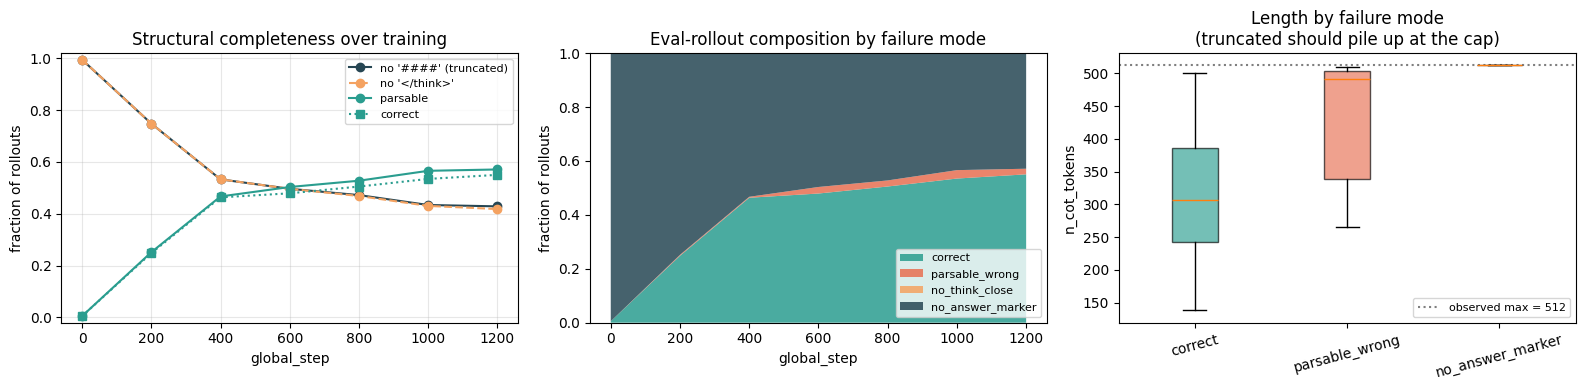

In [2]:
"""Truncation statistics from eval_df.

A rollout is "structurally complete" when both markers are present:
    '</think>' (reasoning closed) AND '####' (parsable answer line).

See ``src.velo_viz.plot_truncation_stats`` for the full breakdown
(per-cycle composition, structural-completeness trends, length by bucket).
"""
from src.velo_viz import plot_truncation_stats

fig, axes, info = plot_truncation_stats(eval_df)
plt.show()


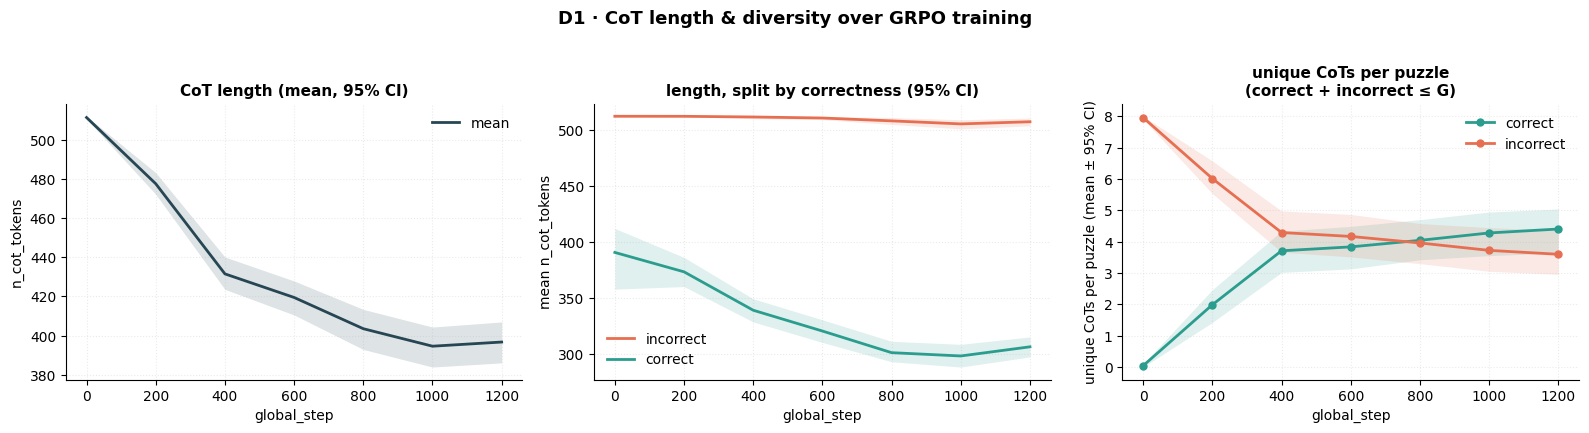

In [3]:
"""Figure 1 · D1: CoT length & diversity over GRPO training.

See ``src.velo_viz.plot_length_and_diversity`` for the full math
(per-step mean length with bootstrap CI, length split by correctness,
per-puzzle unique-CoT count split by correctness).
"""
from src.velo_viz import plot_length_and_diversity

fig, axes, info = plot_length_and_diversity(eval_df)
plt.show()


k                1      4      8
global_step                     
0            0.005  0.021  0.042
200          0.248  0.499  0.611
400          0.464  0.698  0.750
600          0.479  0.703  0.750
800          0.505  0.746  0.819
1000         0.535  0.746  0.806
1200         0.550  0.727  0.778


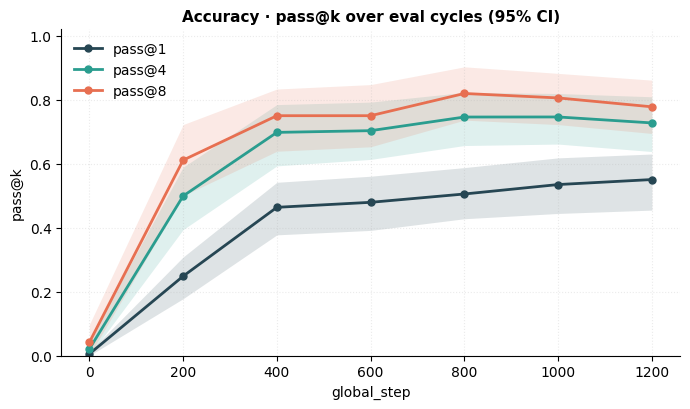

In [4]:
"""Figure 2 · pass@1, pass@4, pass@8 over GRPO training (95% bootstrap CI).

See ``src.velo_viz.plot_pass_at_k`` for the full math (per-puzzle unbiased
estimator over ``num_generations`` rollouts, mean-over-puzzles per cycle,
95% bootstrap CI over puzzles).
"""
from src.velo_viz import plot_pass_at_k

fig, ax, info = plot_pass_at_k(eval_df)
plt.show()


Puzzles with ≥1 canonical solution: 72 / 72
Puzzles where the model EVER found ≥1 solution: 63 / 72
|S(p)| stats: min=4, max=228, mean=48.22
Rollouts per (step,puzzle): mode=8

Diversity collapse:  # unique-correct-now / min(# unique-correct-total, G)
 step   val    lo    hi  n_puzzles
    0 0.016 0.000 0.037         63
  200 0.273 0.207 0.348         63
  400 0.518 0.451 0.598         63
  600 0.483 0.423 0.548         63
  800 0.526 0.463 0.596         63
 1000 0.516 0.451 0.589         63
 1200 0.514 0.438 0.587         63

Cumulative:  # found solutions / # solutions   (over s' ≤ s)
 step   val    lo    hi  n_puzzles
    0 0.004 0.000 0.012         72
  200 0.036 0.022 0.055         72
  400 0.073 0.055 0.093         72
  600 0.091 0.072 0.111         72
  800 0.103 0.081 0.127         72
 1000 0.109 0.086 0.132         72
 1200 0.118 0.091 0.140         72

Novel-fraction:  # novel solutions / # ever-found  (per cycle)
 step   val    lo    hi  n_puzzles
    0 0.016 0.000 0.037    

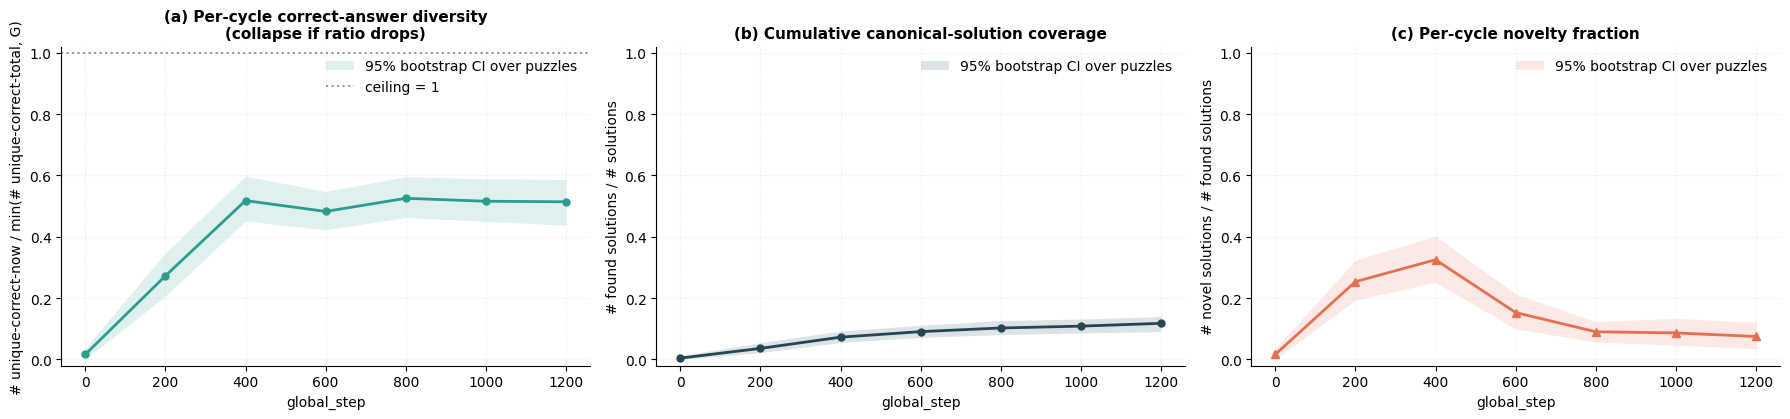

In [5]:
"""Figure · Solution coverage dynamics (3 panels).

See ``src.velo_viz.plot_solution_coverage_dynamics`` for the full math
(per-cycle diversity, cumulative canonical-solution coverage, per-cycle
novelty fraction with denom = ever-found).
"""
from src.velo_viz import plot_solution_coverage_dynamics

fig, axes, cov_info = plot_solution_coverage_dynamics(eval_df)
plt.show()


Tracing puzzle  numbers=[1, 2, 2, 6]  (puzzle #3 of 72)
|S(p)| = 145, G = 8, 7 eval cycles, 56 rollouts total.
Distinct expressions (excl. no-expr): 12  (10 verifier-correct, of which 10 also ∈ enumerate_solutions; 2 verifier-wrong)

Lane summary (birth-ordered):
  ✓ ★ born@step=200  (200:1)   (6 / (1 / 2)) * 2
  ✓ ★ born@step=400  (400:1 800:1)   (6 + 2) * (2 + 1)
  ✓ ★ born@step=400  (400:1 600:1 800:1 1000:1 1200:1)   6*(2+2)*1
  ✓ ★ born@step=600  (600:1 1200:1)   1*2*2*6
  ✓ ★ born@step=600  (600:1 800:3 1200:2)   6*2*2*1
  ✗   born@step=600  (600:1)   6*2*
  ✗   born@step=600  (600:1)   6*2*2
  ✓ ★ born@step=800  (800:1)   6*(2+2)/1
  ✓ ★ born@step=1000  (1000:1)   (2 + 2) * (6 / 1)
  ✓ ★ born@step=1000  (1000:1)   (2 + 2) * 6 * 1
  ✓ ★ born@step=1000  (1000:1)   6*1*2*2
  ✓ ★ born@step=1200  (1200:2)   6*(2 + (2/1))

  ✗  truncated / no expr   (0:8 200:7 400:6 600:3 800:2 1000:4 1200:2)


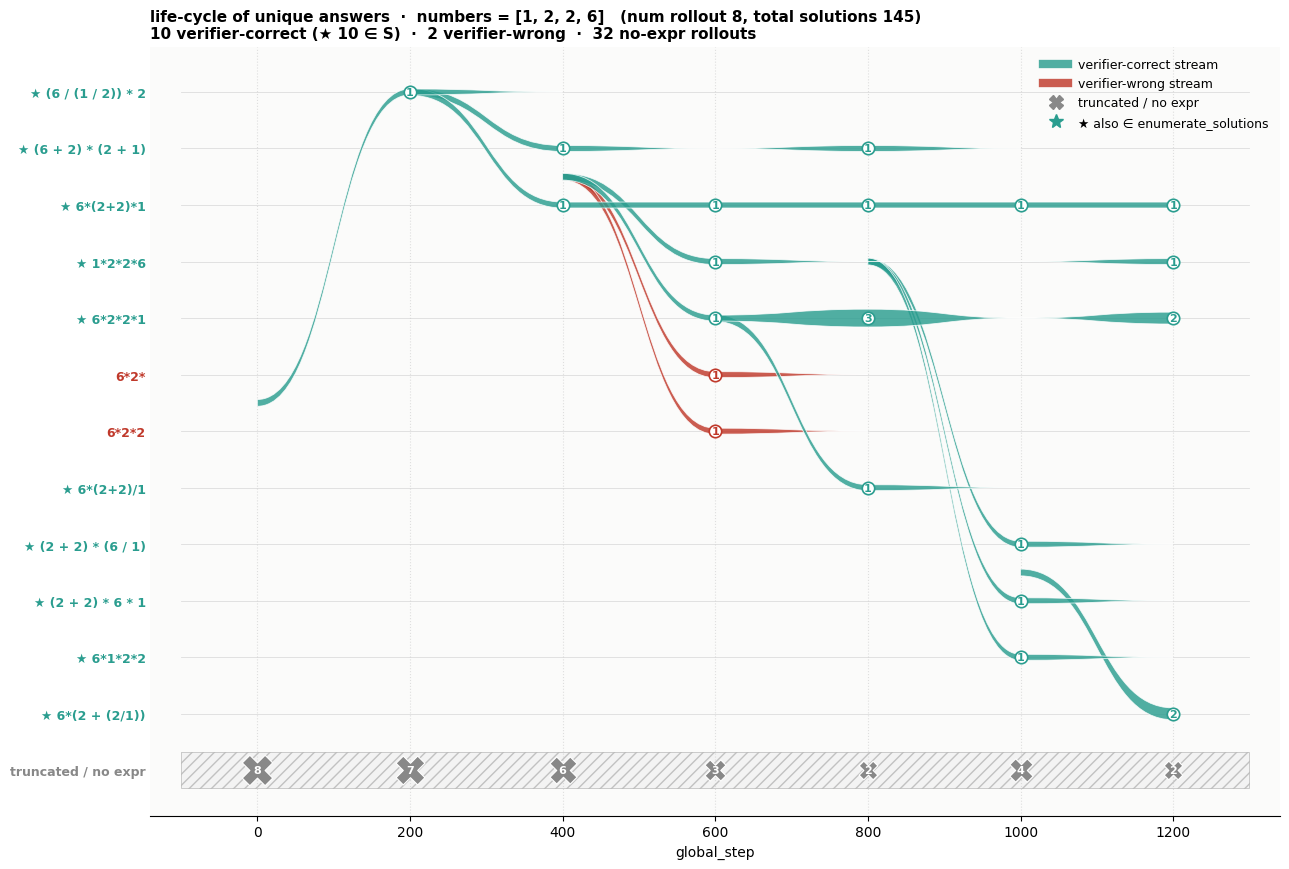

In [11]:
from src.velo_viz import plot_lifecycle_river

# ====== CONFIG ============================================================
IDX     = 3
NUMBERS = None          # e.g. (1, 1, 3, 8) — overrides IDX if set
# ==========================================================================

fig, ax, info = plot_lifecycle_river(
    eval_df,
    idx=IDX,
    numbers=NUMBERS,
)
plt.show()


Median pairwise LCP across all (step, key, pair) = 125.0 chars  →  PREFIX_LEN = 120

Computed LCP for 14,112 pairs across 7 eval cycles.

Within-puzzle top-k 120-char prefix coverage (mean across 72 puzzles):
 step  top1  top2  top3  top4  top5
    0 0.661 0.830 0.929 0.983 0.998
  200 0.774 0.913 0.979 0.997 1.000
  400 0.658 0.880 0.962 0.995 0.998
  600 0.727 0.901 0.976 1.000 1.000
  800 0.738 0.901 0.970 0.993 0.998
 1000 0.705 0.877 0.957 0.993 1.000
 1200 0.698 0.873 0.953 0.990 0.997

=== Representative 120-char prefixes at step 1200 ===
(top-1 share = fraction of the 8 rollouts that share the most-common prefix)

numbers=[2, 2, 2, 8]  top-1 share = 100%  (1 unique prefixes)
  [8/8]  "<think>\\nOkay, let's see. I need to use the numbers 2, 2, 2, 8 exactly once with arithmetic operations to get 24. Hmm. Le"

numbers=[2, 3, 8, 8]  top-1 share = 100%  (1 unique prefixes)
  [8/8]  "<think>\\nOkay, let's see. I need to use the numbers 2, 3, 8, 8 exactly once with arithmetic operatio

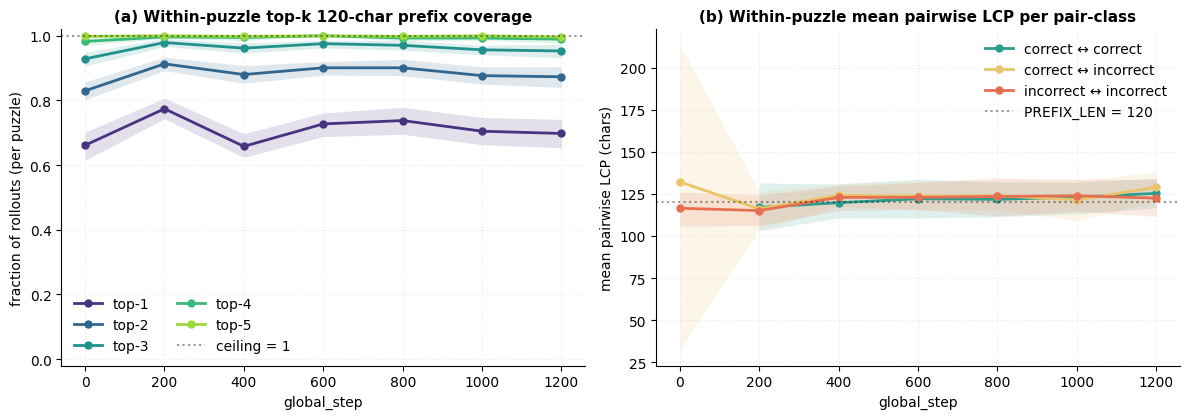

In [7]:
"""Claim 5a · Within-puzzle prefix sharing across rollouts.

See `src.velo_viz.plot_prefix_sharing_dynamics` for the full math
(per-pair-class mean LCP with data-driven PREFIX_LEN, within-puzzle top-k
prefix coverage, 95% bootstrap CIs over puzzles).
"""
from src.velo_viz import plot_prefix_sharing_dynamics

fig, axes, info = plot_prefix_sharing_dynamics(eval_df)
plt.show()


step=1200  rollouts: correct=317  incorrect=259  puzzles total=72  with-both=38


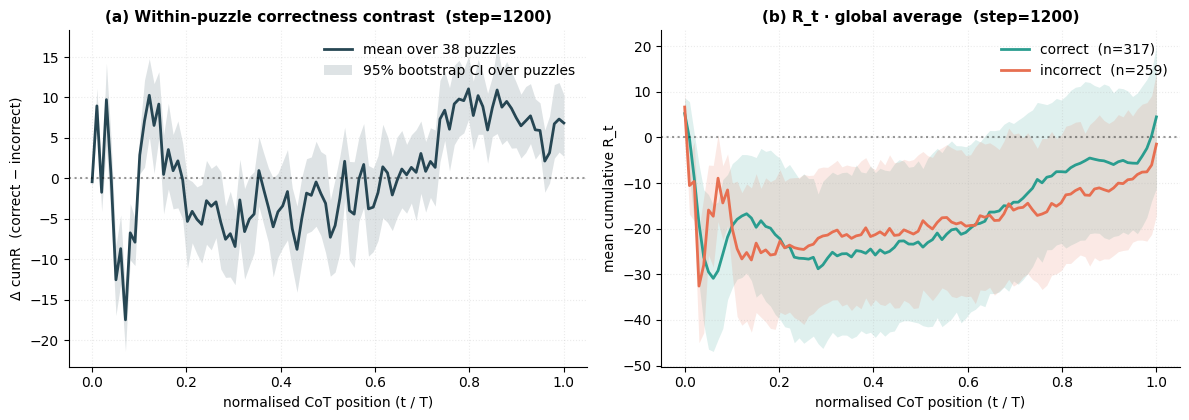

In [8]:
"""Figure 3 · R_t decoding-velocity dynamics at step 1200.

See `src.velo_viz.plot_R_t_correctness_dynamics` for the full math
(per-reference → scalar collapse, within-puzzle correctness contrast with
95% bootstrap CI, global ±1σ marginal split).
"""
from src.velo_viz import plot_R_t_correctness_dynamics

fig, axes, info = plot_R_t_correctness_dynamics(RUN_DIR / "eval_rollout_vt.jsonl")
plt.show()


[diag] vt step→#rows  : {1200: 576}
[diag] eval step→#rows: {0: 576, 200: 576, 400: 576, 600: 576, 800: 576, 1000: 576, 1200: 576}
contrasting on puzzle (4, 4, 5, 8) at step 1200  (7/8 correct)
saved logs/game24_sweep_exp4/len512/Qwen__Qwen3-4B/vt_pair_step1200_4-4-5-8.gif


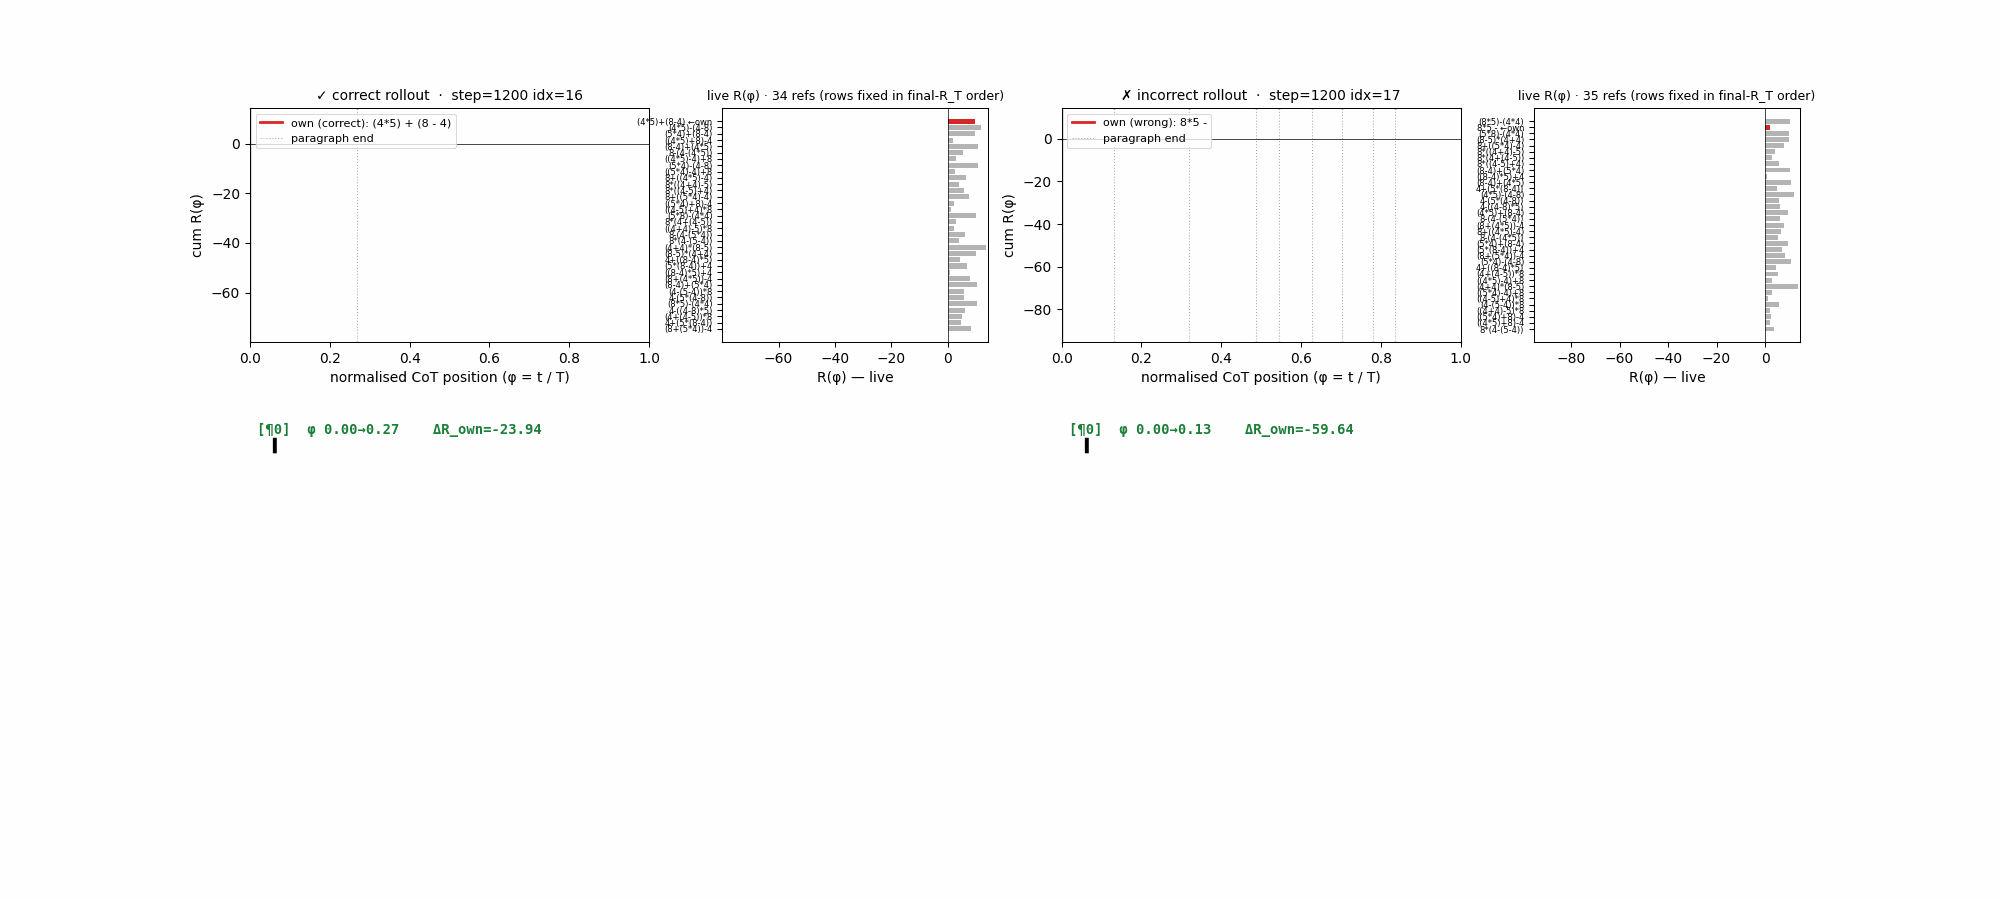

In [14]:
# animate on correct & incorrect rollout on the same query
"""Side-by-side cum R(φ) + text animation for one (correct, incorrect) pair.

Joins vt sidecar rows to the original eval log by file order within a single
eval cycle. We reload the eval log here because the `rows` variable from the
setup cell gets shadowed by later cells.
"""
from collections import Counter, defaultdict
from src.velo_viz import make_pair_animation_from_vt

# reload both logs (don't trust shadowed `rows`)
VT_LOG = RUN_DIR / "eval_rollout_vt.jsonl"
eval_rows_list = [json.loads(l) for l in EVAL_LOG.read_text().splitlines() if l.strip()]
vt_rows_list   = [json.loads(l) for l in VT_LOG.read_text().splitlines()   if l.strip()]

vt_step_counts   = Counter(r["global_step"] for r in vt_rows_list)
eval_step_counts = Counter(r.get("global_step") for r in eval_rows_list if r.get("completion"))
print(f"[diag] vt step→#rows  : {dict(vt_step_counts)}")
print(f"[diag] eval step→#rows: {dict(eval_step_counts)}")

# Pick the latest step that exists on BOTH sides; prefer matching row counts.
common = [s for s in sorted(vt_step_counts) if s in eval_step_counts]
assert common, "no shared global_step between eval_rollout.jsonl and eval_rollout_vt.jsonl"
exact = [s for s in common if vt_step_counts[s] == eval_step_counts[s]]
STEP = (exact or common)[-1]
if STEP not in exact:
    print(f"[warn] step {STEP}: eval={eval_step_counts[STEP]} vs vt={vt_step_counts[STEP]} "
          "(positional alignment may be partial)")

eval_at_step = [r for r in eval_rows_list if r.get("global_step") == STEP and r.get("completion")]
vt_at_step   = [r for r in vt_rows_list   if r["global_step"] == STEP]
n = min(len(eval_at_step), len(vt_at_step))
eval_at_step, vt_at_step = eval_at_step[:n], vt_at_step[:n]

# pick a puzzle (key) that has BOTH a correct and an incorrect rollout at STEP
by_key = defaultdict(list)
for er, vr in zip(eval_at_step, vt_at_step):
    if not er.get("expr"):
        continue
    by_key[tuple(sorted(er["numbers"]))].append((er, vr))

mixed = {k: v for k, v in by_key.items()
         if any(e["correct"] for e, _ in v) and any(not e["correct"] for e, _ in v)}
assert mixed, f"no puzzle at step {STEP} has both correct and incorrect rollouts"

TARGET_KEY = next(iter(mixed))   # change as desired
pool = mixed[TARGET_KEY]
n_ok = sum(1 for e, _ in pool if e["correct"])
print(f"contrasting on puzzle {TARGET_KEY} at step {STEP}  ({n_ok}/{len(pool)} correct)")

er_ok,  vr_ok  = next((e, v) for e, v in pool if e["correct"])
er_bad, vr_bad = next((e, v) for e, v in pool if not e["correct"])

GIF = RUN_DIR / f"vt_pair_step{STEP}_{'-'.join(map(str, TARGET_KEY))}.gif"
make_pair_animation_from_vt(
    vr_ok, er_ok["completion"], vr_bad, er_bad["completion"],
    save_path=str(GIF), fps=10,
)
print(f"saved {GIF}")
from IPython.display import Image
Image(filename=str(GIF))